In [8]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")
print(os.listdir("dataset"))

for root, dirs, files_list in os.walk("dataset"):
    if "train" in dirs and "val" in dirs:
        base = root
        break

print("Dataset path:", base)

IMG_SIZE = 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    base + "/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = datagen.flow_from_directory(
    base + "/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_gen = datagen.flow_from_directory(
    base + "/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Classes:", train_gen.class_indices)

Saving archive (1).zip to archive (1) (2).zip
Dataset extracted successfully!
['train.csv', 'train', 'val.csv', 'val']
Dataset path: dataset
Found 275 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
Classes: {'cat': 0, 'dog': 1}


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu",
           input_shape=(128, 128, 3)),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 992ms/step - accuracy: 0.5745 - loss: 1.0693 - val_accuracy: 0.6571 - val_loss: 0.6489
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 774ms/step - accuracy: 0.6655 - loss: 0.6196 - val_accuracy: 0.6571 - val_loss: 0.6289
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 989ms/step - accuracy: 0.6618 - loss: 0.5804 - val_accuracy: 0.6571 - val_loss: 0.6296
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6909 - loss: 0.5059 - val_accuracy: 0.6571 - val_loss: 0.6636
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8000 - loss: 0.4170 - val_accuracy: 0.6143 - val_loss: 0.6830
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 735ms/step - accuracy: 0.8545 - loss: 0.3570 - val_accuracy: 0.6571 - val_loss: 0.9105
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 947ms/step - accuracy: 0.9091 - loss: 0.2949 - val_accuracy: 0.5857 - val_loss: 0.7242
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 764ms/step - accuracy: 0.9309 - loss: 0.2038 - val_accuracy: 0.6429 - val_loss: 0.

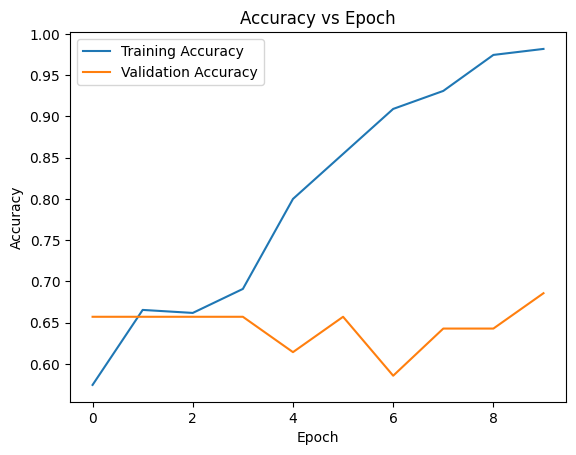

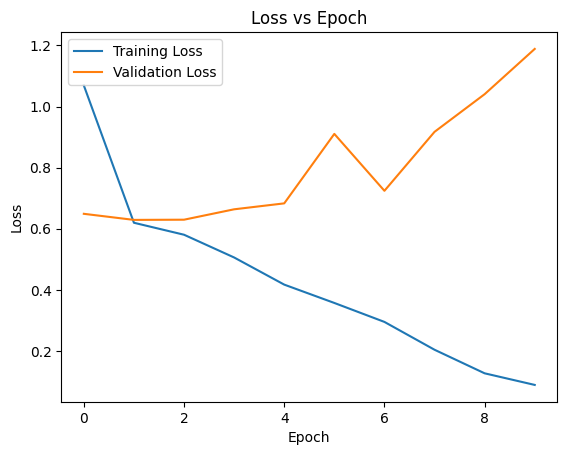

In [5]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)
test_loss, test_accuracy = model.evaluate(test_gen)

print("Testing Accuracy:", test_accuracy)
print("Testing Loss:", test_loss)

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

FINAL PERFORMANCE RESULTS
-----------------------------------
Training Accuracy: 98.18 %
Validation Accuracy: 68.57 %
Training Loss: 0.0887
Validation Loss: 1.1887
Testing Accuracy: 68.57 %
Testing Loss: 1.1887
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step


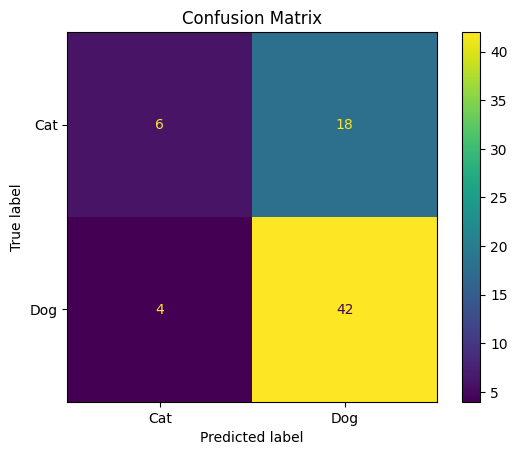

Total Misclassified Images: 22


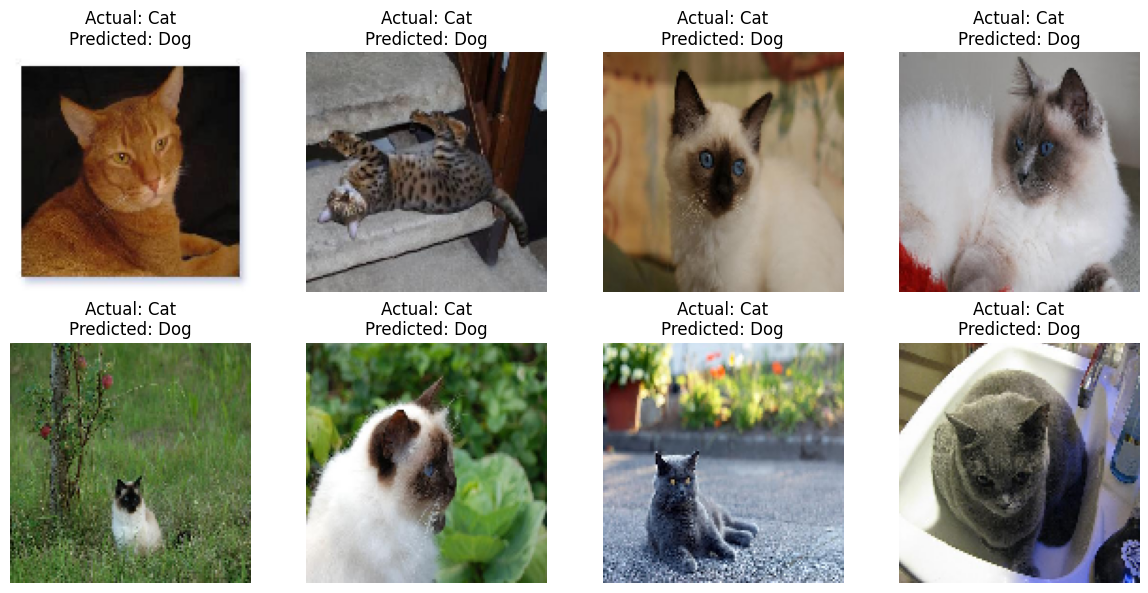

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("FINAL PERFORMANCE RESULTS")
print("-" * 35)

print("Training Accuracy:", round(history.history["accuracy"][-1] * 100, 2), "%")
print("Validation Accuracy:", round(history.history["val_accuracy"][-1] * 100, 2), "%")
print("Training Loss:", round(history.history["loss"][-1], 4))
print("Validation Loss:", round(history.history["val_loss"][-1], 4))

test_loss, test_accuracy = model.evaluate(test_gen, verbose=0)

print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print("Testing Loss:", round(test_loss, 4))

predictions = (model.predict(test_gen) > 0.5).astype(int).flatten()
actual = test_gen.classes

cm = confusion_matrix(actual, predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
).plot()

plt.title("Confusion Matrix")
plt.show()

wrong = np.where(actual != predictions)[0]
print("Total Misclassified Images:", len(wrong))

plt.figure(figsize=(12, 6))

for i, index in enumerate(wrong[:8]):
    img = tf.keras.utils.load_img(
        test_gen.filepaths[index],
        target_size=(128, 128)
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)

    plt.title(
        f"Actual: {['Cat', 'Dog'][actual[index]]}\n"
        f"Predicted: {['Cat', 'Dog'][predictions[index]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()